In [1]:
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler, StandardScaler  # noqa: F401
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

In [2]:
# 재현성을 위한 시드 고정
# (30번 버전에는 없던 부분: 가중치 초기화 / DataLoader shuffle이
#  실행마다 달라져 결과 비교가 어려웠음)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
print(torch.__version__)

2.6.0


# Data Loading

[data] UCI Air Quality Data Set (De Vito et al.)

https://archive.ics.uci.edu/dataset/360/air+quality

In [4]:
file_path = "./data/AirQualityUCI.csv" 

In [5]:
_df = pd.read_csv(file_path, sep=";")
_df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


# Preprocessing

In [6]:
df = _df[["Date", "Time", "CO(GT)"]].copy()
df.head()

,Date,Time,CO(GT)
0,10/03/2004,18.00.00,"2,6"
1,10/03/2004,19.00.00,2
2,10/03/2004,20.00.00,"2,2"
3,10/03/2004,21.00.00,"2,2"
4,10/03/2004,22.00.00,"1,6"


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    9357 non-null   object
 1   Time    9357 non-null   object
 2   CO(GT)  9357 non-null   object
dtypes: object(3)
memory usage: 222.1+ KB


In [8]:
# 날짜 컬럼 처리
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"], format="%d/%m/%Y %H.%M.%S", errors="coerce"
)

df.head()

,Date,Time,CO(GT),datetime
0,10/03/2004,18.00.00,"2,6",2004-03-10 18:00:00
1,10/03/2004,19.00.00,2,2004-03-10 19:00:00
2,10/03/2004,20.00.00,"2,2",2004-03-10 20:00:00
3,10/03/2004,21.00.00,"2,2",2004-03-10 21:00:00
4,10/03/2004,22.00.00,"1,6",2004-03-10 22:00:00


In [9]:
df[df["datetime"].isna() & df["CO(GT)"].notna()]

,Date,Time,CO(GT),datetime


In [10]:
# datetime 컬럼만 남기도 처리
df.set_index("datetime", inplace=True)
df.drop(columns=["Date", "Time"], inplace=True)
df.dropna(inplace=True)

df.head()

,CO(GT)
datetime,
2004-03-10 18:00:00,"2,6"
2004-03-10 19:00:00,2
2004-03-10 20:00:00,"2,2"
2004-03-10 21:00:00,"2,2"
2004-03-10 22:00:00,"1,6"


In [11]:
# CO(GT) 컬럼 처리
df["CO(GT)"] = df["CO(GT)"].str.replace(",", ".").astype(float)

df.head()

,CO(GT)
datetime,
2004-03-10 18:00:00,2.6
2004-03-10 19:00:00,2.0
2004-03-10 20:00:00,2.2
2004-03-10 21:00:00,2.2
2004-03-10 22:00:00,1.6


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CO(GT)  9357 non-null   float64
dtypes: float64(1)
memory usage: 146.2 KB


## [수정] 결측치 마커(-200) 처리

이 데이터셋은 센서 결측/오류 값을 `NaN`이 아니라 **-200**으로 인코딩한다(UCI 문서 기준).
30번 버전에서는 이를 확인하지 않고 "0보다 작은 값은 0으로 대체"하는 식으로 처리했는데,
이는 실제로는 **결측치를 유효한 0 mg/m^3 측정값으로 둔갑시키는 것**과 같다.

아래에서 -200의 비중을 먼저 확인하고, `NaN`으로 되돌린 뒤 시계열 특성을 살려 시간 기반 보간으로 채운다.

In [13]:
# -200 마커 비중 확인
n_missing_marker = (df["CO(GT)"] == -200).sum()
print(f"-200(결측 마커) 개수: {n_missing_marker} / {len(df)} ({n_missing_marker / len(df):.1%})")

-200(결측 마커) 개수: 1683 / 9357 (18.0%)


In [14]:
# 결측 마커(-200) -> NaN 복원
df["CO(GT)"] = df["CO(GT)"].replace(-200, np.nan)
print("NaN 처리 직후 결측치 개수:", df["CO(GT)"].isnull().sum())

NaN 처리 직후 결측치 개수: 1683


In [15]:
# 결측치 최종 확인 (보간 전)
df.isnull().sum()

CO(GT)    1683
dtype: int64

# EDA

In [16]:
print(f"데이터 기간: {df.index.min()} ~ {df.index.max()}")

데이터 기간: 2004-03-10 18:00:00 ~ 2005-04-04 14:00:00


In [17]:
# datetime의 결측값 확인 (인덱스 자체에 누락된 시간대가 있는지)
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h")
missing_times = full_range.difference(df.index)

print(f"누락된 시간 개수: {len(missing_times)}")
print(missing_times)

누락된 시간 개수: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='H')


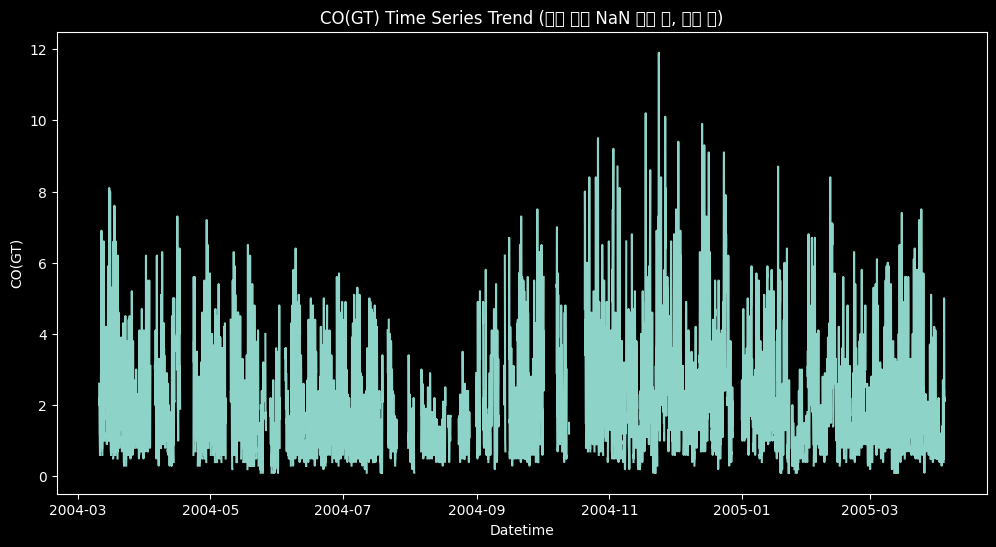

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["CO(GT)"])

plt.title("CO(GT) Time Series Trend (결측 마커 NaN 처리 후, 보간 전)")
plt.xlabel("Datetime")
plt.ylabel("CO(GT)")
plt.show()

In [19]:
df.describe()

,CO(GT)
count,7674.000000
mean,2.152750
std,1.453252
min,0.100000
25%,1.100000
50%,1.800000
75%,2.900000
max,11.900000


## [수정] 결측치 보간

인덱스 자체에는 누락된 시간대가 없으므로(위 확인 결과 0개), 값이 -200 -> NaN으로 바뀐
지점만 시간 기반 선형 보간(`interpolate(method="time")`)으로 채운다. 이렇게 하면 시퀀스를
만들 때(24시간 슬라이딩 윈도우) 시간축의 연속성이 그대로 유지된다.

(30번 버전의 "음수면 0으로 치환"은 제거함 — 위에서 확인했듯 음수는 전부 -200 결측 마커였고,
정상적인 CO 농도는 음수가 될 수 없으므로 애초에 "0 미만 클리핑"이라는 접근 자체가
결측치 처리 문제를 감춘 것이었음.)

In [20]:
df["CO(GT)"] = df["CO(GT)"].interpolate(method="time")
# 혹시 양 끝단에 NaN이 남아 있으면 앞/뒤 값으로 채움
df["CO(GT)"] = df["CO(GT)"].ffill().bfill()

print("보간 후 결측치 개수:", df["CO(GT)"].isnull().sum())
df.describe()

보간 후 결측치 개수: 0


,CO(GT)
count,9357.000000
mean,2.130603
std,1.431736
min,0.100000
25%,1.100000
50%,1.800000
75%,2.900000
max,11.900000


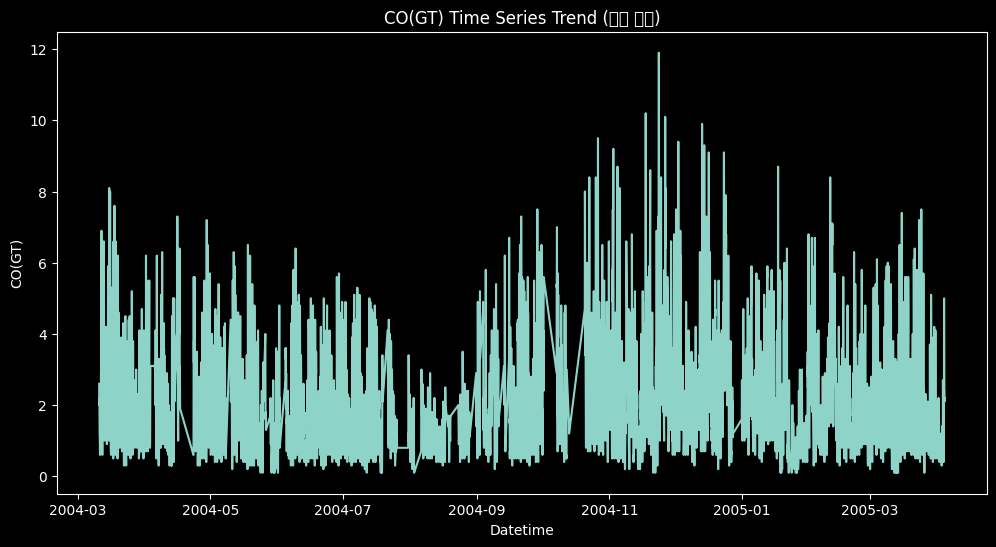

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["CO(GT)"])
plt.title("CO(GT) Time Series Trend (보간 완료)")
plt.xlabel("Datetime")
plt.ylabel("CO(GT)")
plt.show()

**변수가 하나라도 표준화 처리가 필요한 이유**

- 수렴 속도 : 값의 범위를 작게 맞춰주면 경사하강법이 더 빨리 수렴함
- 안정성 : 큰 값이나 작은값 때문에 모델이 불안정해지는 것을 방지 (LOSS가 진동하면서 수렴이 되지 않는 현상 발생)

**[수정]** 
- 표준화(스케일링)는 이 시점에 바로 적용하지 않음. 
- 아래 "Train / Val / Test Split"에서 
    - 먼저 시간 순서대로 데이터를 분할한 뒤, 
    - **train 구간에만 `fit`** 하고 val/test에는 `transform`만 적용. 
- 30번 버전은 분할 전 전체 데이터에 `fit_transform`을 적용해 
    - test 구간의 평균/표준편차가 전처리 단계에서 이미 학습에 유입되는 
    - 데이터 누수(look-ahead bias)가 있었음.

**SEQ_LENGTH**

- 과거 24시간(1일) 데이터를 보고 다음 시간대의 CO 농도를 에측하도록 설정
- 근거 : 하루(24시간) 주기가 반복되는 경향성 고려
    - 출퇴근 시간 : 오전, 저녁에 차량 증가 -> 오염 증가
    - 밤 시간대 : 차량 이동 적음 -> 오염 감소

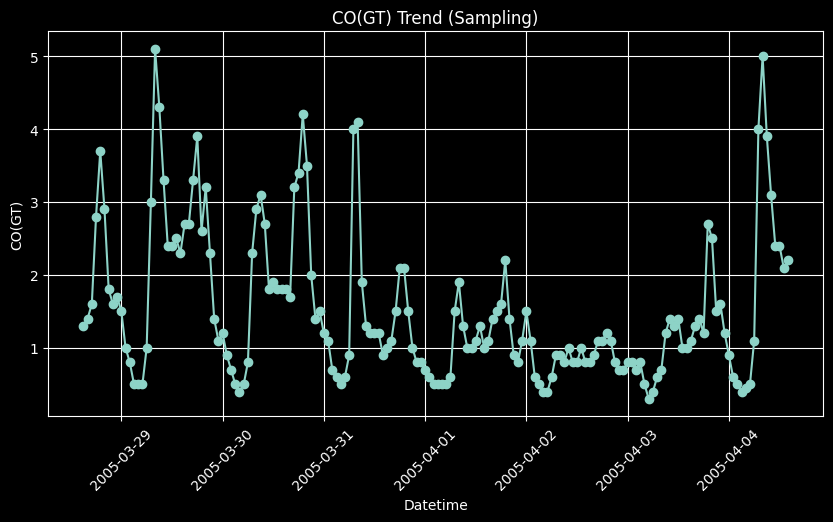

In [22]:
# 7일치 트렌드 확인
sample_days = df.last("7D")

plt.figure(figsize=(10, 5))
plt.plot(sample_days.index, sample_days["CO(GT)"], marker="o")

plt.title("CO(GT) Trend (Sampling)")
plt.xlabel("Datetime")
plt.ylabel("CO(GT)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Train / Val / Test Split

## [수정] Validation set 추가 + 분할 순서 변경

30번 버전은 (1) validation set이 없었고, (2) 전체 데이터에 스케일러를 먼저 적용한 뒤
슬라이딩 윈도우를 만들고 나서 `train_test_split`으로 나눴다. 이 순서에서는

- 스케일러가 test 구간 통계까지 학습해버리는 누수
- 윈도우를 먼저 만들고 자르기 때문에 train의 마지막 윈도우와 test의 첫 윈도우가
  최대 23개 타임스텝을 서로 공유(경계부 중첩)

두 가지 문제가 함께 발생한다.

이번 버전은 **시간 순서 그대로(셔플 없이) 원본 시계열을 먼저 train/val/test로 분할**하고,
스케일링과 시퀀스(윈도우) 생성을 **분할 이후, 각 구간 내부에서 독립적으로** 수행한다.
비율은 70% / 15% / 15%로 설정했다(모두 시간 순서상 앞 -> 뒤 순서, shuffle 없음).

In [23]:
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
# 나머지(15%)는 test

n = len(df)
n_train = int(n * TRAIN_RATIO)
n_val = int(n * VAL_RATIO)

train_df = df.iloc[:n_train]
val_df = df.iloc[n_train : n_train + n_val]
test_df = df.iloc[n_train + n_val :]

print(f"train: {len(train_df)} ({len(train_df) / n:.1%})")
print(f"val  : {len(val_df)} ({len(val_df) / n:.1%})")
print(f"test : {len(test_df)} ({len(test_df) / n:.1%})")
print(f"train 기간: {train_df.index.min()} ~ {train_df.index.max()}")
print(f"val   기간: {val_df.index.min()} ~ {val_df.index.max()}")
print(f"test  기간: {test_df.index.min()} ~ {test_df.index.max()}")

train: 6549 (70.0%)
val  : 1403 (15.0%)
test : 1405 (15.0%)
train 기간: 2004-03-10 18:00:00 ~ 2004-12-08 14:00:00
val   기간: 2004-12-08 15:00:00 ~ 2005-02-05 01:00:00
test  기간: 2005-02-05 02:00:00 ~ 2005-04-04 14:00:00


In [24]:
# [수정] 스케일러는 train에만 fit, val/test는 transform만 적용 (데이터 누수 방지)
# scaler = MinMaxScaler()
scaler = StandardScaler()

train_data = scaler.fit_transform(train_df)
val_data = scaler.transform(val_df)
test_data = scaler.transform(test_df)

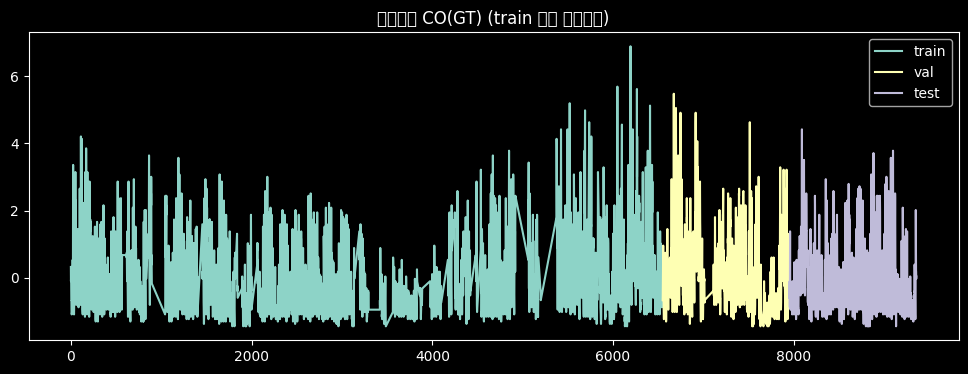

In [25]:
plt.figure(figsize=(12, 4))
plt.plot(range(len(train_data)), train_data, label="train")
plt.plot(range(len(train_data), len(train_data) + len(val_data)), val_data, label="val")
plt.plot(
    range(len(train_data) + len(val_data), len(train_data) + len(val_data) + len(test_data)),
    test_data,
    label="test",
)
plt.legend()
plt.title("표준화된 CO(GT) (train 기준 스케일러)")
plt.show()

# Data Definition

## [수정] 시퀀스(윈도우)를 분할 이후 각 구간 내부에서 생성

30번 버전은 전체 데이터로 윈도우를 만든 뒤 잘랐지만, 이번에는 train/val/test 각각의
연속 구간 안에서만 슬라이딩 윈도우를 만든다. 따라서 구간 경계를 넘나드는 윈도우가 없고,
train↔val↔test 사이에 시간적으로 겹치는 샘플이 존재하지 않는다.

In [26]:
seq_length = 24


def make_sequences(data: np.ndarray, seq_length: int):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)


X_train, y_train = make_sequences(train_data, seq_length)
X_val, y_val = make_sequences(val_data, seq_length)
X_test, y_test = make_sequences(test_data, seq_length)

In [27]:
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}, y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")

X_train: (6525, 24, 1), y_train: (6525, 1)
X_val  : (1379, 24, 1), y_val  : (1379, 1)
X_test : (1381, 24, 1), y_test : (1381, 1)


In [28]:
# 텐서 변환
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [29]:
X_train.shape

torch.Size([6525, 24, 1])

# DataLoader 구성

- 시계열 윈도우 하나(과거 24시간 → 다음 1시간)를 독립적인 학습 샘플로 보고, 미니배치 단위로 나누어 학습.
- 학습 로더만 `shuffle=True` 로 두어 배치 구성의 다양성을 확보(각 윈도우 **내부**의 시간 순서는 그대로 보존됨).
- **[추가]** validation 로더를 추가로 구성(shuffle=False, test와 동일한 방식).

In [30]:
# 하이퍼파라미터
# 미니배치 크기 (한 번의 가중치 갱신에 쓰는 샘플 수)
BATCH_SIZE = 64

In [31]:
# 텐서들을 (입력, 정답) 쌍으로 묶어 Dataset 구성
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# 학습 로더: 배치마다 순서를 섞어 학습 안정성/일반화에 도움
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# 검증/평가 로더: 시간 순서 유지 위해 섞지 않음
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"train 배치 개수: {len(train_loader)}")
print(f"val   배치 개수: {len(val_loader)}")
print(f"test  배치 개수: {len(test_loader)}")

train 배치 개수: 102
val   배치 개수: 22
test  배치 개수: 22


# Architecture

In [32]:
class LSTMModel(nn.Module):
    """
    LSTM 기반 시계열 예측 모델
    - 입력: (batch_size, seq_length, input_size)
    - 출력: (batch_size, 1) -> 다음 시점의 CO 농도 예측
    - LSTM은 내부적으로 tanh 활성화가 기본 적용되므로 별도 코드 불필요
    """

    def __init__(self, input_size=1, hidden_size=50, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        # input_size=1  : 입력 특성 1개 (CO 농도)
        # hidden_size=50: 은닉 상태 차원 (기억 용량)
        # num_layers=2  : LSTM 층 2개 (다층)
        # batch_first=True: 입력 형태를 (batch, seq, feature)로 사용
        # dropout: 다층(num_layers>1)일 때 층 사이에 적용되어 과적합 완화
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )

        # 마지막 hidden state(50차원) -> 예측값 1개로 변환
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        """
        :param x: (batch_size, seq_length, input_size)
        :return:  (batch_size, 1) 다음 시점 CO 농도 예측
        """
        # out: (batch_size, seq_length, hidden_size)
        out, _ = self.lstm(x)

        # 시퀀스의 마지막 타임스텝 hidden state만 사용해 예측
        out = self.fc(out[:, -1, :])
        return out

# Training

## [수정] Validation 기반 Early Stopping 추가

30번 버전은 학습 손실(train loss)만 기록하며 고정된 30 epoch을 그대로 학습했기 때문에
과적합 여부를 확인할 방법이 없었다. 이번에는 epoch마다 validation loss를 함께 계산하고,
`patience` epoch 동안 validation loss가 개선되지 않으면 학습을 조기 종료한 뒤
**validation loss가 가장 낮았던 시점의 가중치**를 최종 모델로 사용한다.

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel().to(device)

criterion = nn.MSELoss()  # 회귀 문제 -> MSE
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100  # early stopping이 있으므로 상한을 넉넉히 잡음
patience = 7  # validation loss가 이 횟수만큼 연속으로 개선되지 않으면 중단
min_delta = 1e-6  # 개선으로 인정할 최소 변화량

train_losses = []  # 에폭별 학습 손실 기록
val_losses = []  # 에폭별 검증 손실 기록

best_val_loss = float("inf")
best_state_dict = None
epochs_no_improve = 0

In [34]:
for epoch in range(num_epochs):
    # ---- Train ----
    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        # 배치를 연산 디바이스로 이동
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()  # 이전 스텝 기울기 초기화
        outputs = model(batch_X)  # 순전파: (batch, 1)
        loss = criterion(outputs, batch_y)  # 손실 (outputs, batch_y 모두 (batch,1))
        loss.backward()  # 역전파
        optimizer.step()  # 가중치 갱신

        # 배치 크기로 가중해 누적(마지막 배치가 작을 수 있으므로)
        running_loss += loss.item() * batch_X.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)  # 에폭 평균 MSE
    train_losses.append(epoch_train_loss)

    # ---- Validation ----
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_running_loss += loss.item() * batch_X.size(0)

    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Train MSE: {epoch_train_loss:.4f} (RMSE {epoch_train_loss ** 0.5:.4f}), "
        f"Val MSE: {epoch_val_loss:.4f} (RMSE {epoch_val_loss ** 0.5:.4f})"
    )

    # ---- Early Stopping 체크 ----
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nValidation loss가 {patience} epoch 연속 개선되지 않아 조기 종료합니다. "
                  f"(epoch {epoch + 1}, best val MSE: {best_val_loss:.4f})")
            break

# 검증 손실이 가장 낮았던 시점의 가중치로 복원
model.load_state_dict(best_state_dict)

Epoch [1/100], Train MSE: 0.6187 (RMSE 0.7866), Val MSE: 0.3788 (RMSE 0.6154)
Epoch [2/100], Train MSE: 0.2532 (RMSE 0.5032), Val MSE: 0.2540 (RMSE 0.5040)
Epoch [3/100], Train MSE: 0.2132 (RMSE 0.4618), Val MSE: 0.2519 (RMSE 0.5019)
Epoch [4/100], Train MSE: 0.1968 (RMSE 0.4436), Val MSE: 0.2360 (RMSE 0.4858)
Epoch [5/100], Train MSE: 0.1832 (RMSE 0.4280), Val MSE: 0.2255 (RMSE 0.4749)
Epoch [6/100], Train MSE: 0.1758 (RMSE 0.4193), Val MSE: 0.2213 (RMSE 0.4704)
Epoch [7/100], Train MSE: 0.1709 (RMSE 0.4134), Val MSE: 0.2160 (RMSE 0.4647)
Epoch [8/100], Train MSE: 0.1671 (RMSE 0.4088), Val MSE: 0.2126 (RMSE 0.4611)
Epoch [9/100], Train MSE: 0.1663 (RMSE 0.4078), Val MSE: 0.2182 (RMSE 0.4671)
Epoch [10/100], Train MSE: 0.1582 (RMSE 0.3978), Val MSE: 0.2113 (RMSE 0.4597)
Epoch [11/100], Train MSE: 0.1598 (RMSE 0.3997), Val MSE: 0.2091 (RMSE 0.4572)
Epoch [12/100], Train MSE: 0.1557 (RMSE 0.3945), Val MSE: 0.2165 (RMSE 0.4653)
Epoch [13/100], Train MSE: 0.1549 (RMSE 0.3936), Val MSE: 0.2

<All keys matched successfully>

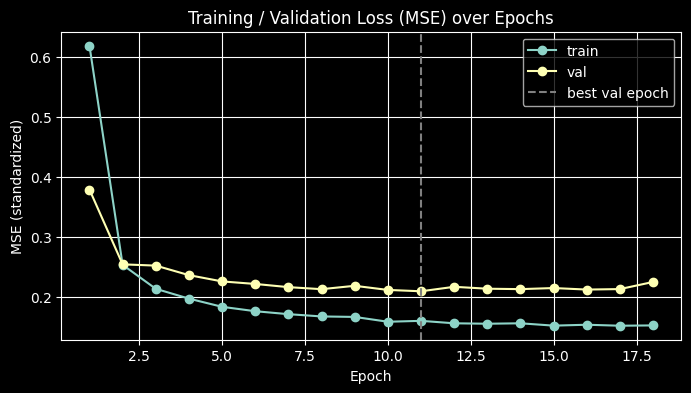

In [35]:
# 학습 곡선 확인 (train / val loss가 실제로 감소하는지, 과적합 시작 지점은 어디인지)
trained_epochs = len(train_losses)

plt.figure(figsize=(8, 4))
plt.plot(range(1, trained_epochs + 1), train_losses, marker="o", label="train")
plt.plot(range(1, trained_epochs + 1), val_losses, marker="o", label="val")
plt.axvline(
    x=val_losses.index(min(val_losses)) + 1,
    color="gray",
    linestyle="--",
    label="best val epoch",
)

plt.title("Training / Validation Loss (MSE) over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE (standardized)")
plt.legend()
plt.grid(True)
plt.show()

# Evaluation

- (validation으로 선택된 best 모델을 기준으로) 평가 로더를 순회하며 배치별 예측을 모아 전체 예측
- 예측과 정답 형상을 모두 `(N, 1)` 로 맞춰 **Test MSE/RMSE** 계산

In [36]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        out = model(batch_X)  # (batch, 1)
        all_preds.append(out.cpu())
        all_targets.append(batch_y)  # 이미 (batch, 1)

# 배치들을 이어 붙여 전체 예측/정답 구성 -> 둘 다 (N, 1)
predictions = torch.cat(all_preds, dim=0)
y_true = torch.cat(all_targets, dim=0)

# 형상이 동일하므로 브로드캐스팅 없이 올바른 오차가 계산됨
test_mse = criterion(predictions, y_true).item()
test_rmse = test_mse**0.5

print(f"predictions shape: {tuple(predictions.shape)}")
print(f"y_true shape     : {tuple(y_true.shape)}")
print(f"Test Loss (MSE)  : {test_mse:.4f}")
print(f"Test RMSE        : {test_rmse:.4f}")

predictions shape: (1381, 1)
y_true shape     : (1381, 1)
Test Loss (MSE)  : 0.1541
Test RMSE        : 0.3925


# Results

In [37]:
# 표준화된 값을 원래 CO(GT) 스케일로 복원 (train에 fit한 스케일러 사용)
pred_inv = scaler.inverse_transform(predictions.numpy())  # (N, 1)
true_inv = scaler.inverse_transform(y_true.numpy())  # (N, 1)

# 실제 단위(mg/m^3) 기준 RMSE도 함께 확인
orig_rmse = np.sqrt(np.mean((pred_inv - true_inv) ** 2))
print(f"Test RMSE (원 스케일): {orig_rmse:.4f}")

Test RMSE (원 스케일): 0.5553


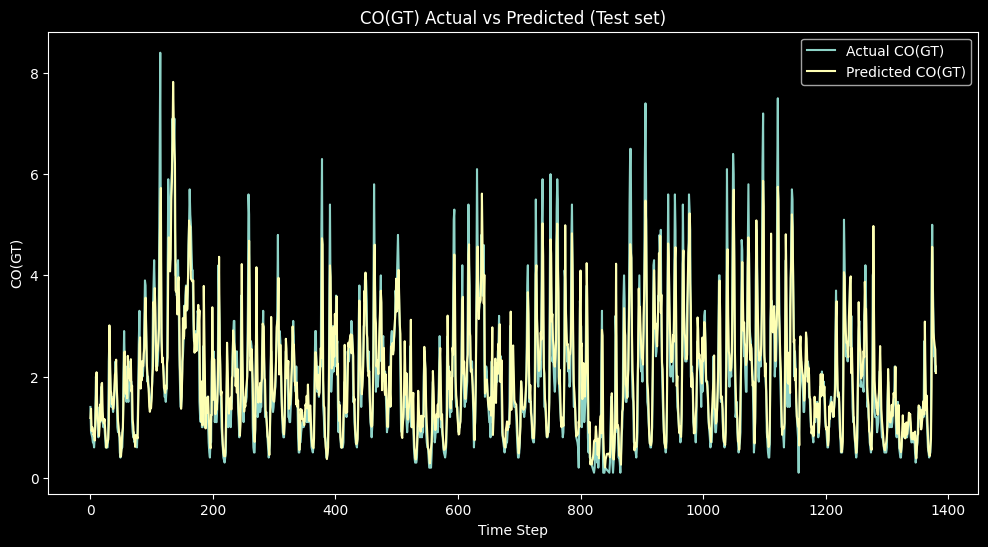

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(true_inv, label="Actual CO(GT)")
plt.plot(pred_inv, label="Predicted CO(GT)")

plt.legend()
plt.title("CO(GT) Actual vs Predicted (Test set)")
plt.xlabel("Time Step")
plt.ylabel("CO(GT)")
plt.show()

---

## 변경 사항 요약 (30 -> 31)

1. **Validation set 추가 + Early Stopping**: train loss만 보던 방식에서 벗어나, 매 epoch validation loss를 계산하고 조기 종료 및 best 모델 저장을 적용.
2. **스케일러 데이터 누수 제거**: 표준화를 train/val/test 분할 이후, train 구간에만 `fit`하도록 변경.
3. **분할 순서 변경(윈도우 중첩 제거)**: 원본 시계열을 시간 순으로 먼저 train/val/test로 나눈 뒤, 각 구간 내부에서만 슬라이딩 윈도우를 생성하도록 변경(구간 경계를 넘는 윈도우 중첩 제거).
4. **결측치(-200 마커) 처리**: "0 미만이면 0으로 치환"하던 로직을 제거하고, -200을 NaN으로 되돌린 뒤 시간 기반 보간으로 채우도록 수정.
5. **데이터셋 설명 정정**: "베이징 다지역 대기질 데이터" 링크/설명을 실제 데이터(UCI Air Quality Data Set, 이탈리아 단일 지점 센서)에 맞게 수정.
6. **재현성**: random/numpy/torch 시드 고정 추가.
7. **기타**: 컬럼 슬라이스에 `.copy()`를 추가해 `SettingWithCopyWarning` 방지.

---
End of Documents